In [1]:
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import auri
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

c:\Users\USER\Documents\openeais\.venv\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
pd.options.display.float_format = "{:,.0f}".format

### - 건축물대장 층별개요 2023년12월 기준 파일을 데이터프레임에 저장


In [3]:
df_floor = dd.read_parquet(
    "data\건축물대장_층별개요_2015년_12월", calculate_divisions=True
)
df_floor.columns

Index(['대지_위치', '도로명_대지_위치', '건물_명', '시군구_코드',
       '법정동_코드', '대지_구분_코드', '번', '지', '특수지_명', '블록',
       '로트', '새주소_도로_코드', '새주소_법정동_코드',
       '새주소_지상지하_코드', '새주소_본_번', '새주소_부_번', '동_명',
       '층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '주_부속_구분_코드_명',
       '면적_제외_여부', '생성_일자'],
      dtype='object')

In [4]:
df_floor.dtypes

대지_위치               string[pyarrow]
도로명_대지_위치        string[pyarrow]
건물_명                 string[pyarrow]
시군구_코드             string[pyarrow]
법정동_코드             string[pyarrow]
대지_구분_코드          string[pyarrow]
번                      string[pyarrow]
지                      string[pyarrow]
특수지_명               string[pyarrow]
블록                    string[pyarrow]
로트                    string[pyarrow]
새주소_도로_코드        string[pyarrow]
새주소_법정동_코드      string[pyarrow]
새주소_지상지하_코드    string[pyarrow]
새주소_본_번                      Int64
새주소_부_번                      Int64
동_명                   string[pyarrow]
층_구분_코드            string[pyarrow]
층_구분_코드_명         string[pyarrow]
층_번호                           Int64
층_번호_명              string[pyarrow]
구조_코드               string[pyarrow]
구조_코드_명            string[pyarrow]
기타_구조               string[pyarrow]
주_용도_코드            string[pyarrow]
주_용도_코드_명         string[pyarrow]
기타_용도               string[pyarrow]
면적(㎡)                        float64
주_부속_

### - 층별개요 컬럼 중 필요한 것 만 가져와서 데이터를 가볍게 함


In [5]:
df_floor = df_floor[
    [
        "층_구분_코드",
        "층_구분_코드_명",
        "층_번호",
        "층_번호_명",
        "구조_코드",
        "구조_코드_명",
        "기타_구조",
        "주_용도_코드",
        "주_용도_코드_명",
        "기타_용도",
        "면적(㎡)",
        "주_부속_구분_코드",
        "면적_제외_여부",
        "생성_일자",
    ]
]

In [6]:
df_floor.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",162,0,<NA>,20111021
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,387,0,<NA>,20111021
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,382,0,<NA>,20111021
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,220,0,<NA>,20111021
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,88,0,<NA>,20150821


### - 층별개요 기초적인 통계를 산출

1. 전국 건축물 층수 합 : 전체 레코드 수(합계, 지상층수 합계, 지하층수 합계) -> 산출방법 : 층*구분*코드 별로 레코드 수의 합계를 구함 -> value_counts() -> 20 : 지상, 10 : 지하, 30 : 옥탑, 21 : 복수층(하층), 22 : 복수층(상층), 40 : 각층(집합건축물 전유부 공용부분)

전국 건축물의 지상 층수의 합계는 18,918,491개 층이며, 지하 층수의 합계는 1,520,078개 층이다. 기타로 옥탑은 417,735개가 있으며, 복수층은 6개, 각층은 216개가 있다. 이를 모두 합한 전체 층의 합계는 20,857,076 층이다.

2. 층별 면적의 최대, 최소, 미기재 등 : 층별 면적이 미기재 된 것은 32,333개 층이다. 단일 층으로 최대 면적은 188,957,549.0의 경기 김포의 한강신도시 롯데캐슬의 지하층 부대시설이나 해당 건축물의 표제부 확인 결과 부용도로 대장을 확인할 수 없고 총괄표제부에 기록된 내용도 일치하는 항목을 찾을 수 없음. 따라서 부용도의 경우 층별개요의 연면적이 오류, 결측 등이 다 수 있는 것으로 추정되어, 층별개요의 주용도 중 단일 층 상위 100개 데이터로 확인하고자 함

3. 건축물의 층 중 주용도 층은 19,125,575 개이며, 부용도 층은 1,722,063 개로 확인되며, 주용도 층 중 면적의 최대값은 5,702,939.0으로 이역시 동의하기 어려운 값으로 일반건축물대장 확인 결과 충남 서천에 위치한 공장으로 지상 3층에 기계실로 확인되며, 연면적이 147,691.26으로 콤마 오기로 1000배의 수치가 반영된 것으로 추정

4. 이에, 층별 면적이 표제부 또는 일반건축물대장의 연면적보다 큰 경우는 오기로 보는 것이 타당하여 레코드를 삭제할 필요가 있음


### - 데이터셋 구축 방안

A. 표제부를 기준으로 층별개요에서 필요한 값을 표제부에 붙여서 계산하는 방법

-   건축물의 용도를 기준으로 한다면 제2롯데월드와 같은 대규모 건축물에서 특정 용도면적이 통합되는 경향이 발생할 수 있다.
-   건축물 연령은 단위면적으로 보는 것이 타당하다.
-   동수와 면적을 동시에 활용하는 것이 중요하다면 이방법으로 하는 것이 좋다.
-   부속용도는 삭제해야한다. 연면적에 이미 해당 면적이 포함된다. 이 경우 입체적이라는 장점이 있다.

B. 층별개요를 기준으로 표제부의 사용승인일을 붙여서 계산하는 방법

-   표제부의 사용승인일이 미기재된 것은 삭제... 연령을 알 수가 없다.
-   용도를 층별로 구분하기 때문에 용도가 중요한 경우 이렇게 해야한다.
-   부속용도는 삭제하는 것이 관리가 용이하다. 다만 이경우 건물을 입체로 본다면 현실과는 다르다.

C. 데이터셋 구축 절차

1. 다운로드(표제부, 층별개요)
2. 표제부 사용승인일 가공(사용승인일 표준화 및 데이터 정제)
3. 표제부 키값 및 사용승인일, 주소, 연면적 데이터셋 생성(데이터컬럼 정리)
4. 층별개요 데이터셋 정리(데이터컬럼 정리)
5. 층별개요 데이터셋에 표제부 데이터셋 결합
6. 연령지수 데이터셋 생성
7. 데이터 2차 정제(부속용도, 사용승인일 미기재 삭제 등)

-   건축물 연령을 보는 이유는?

1. 지역별 노후건축물 현황 파악과 미래 예측 -> 공공에서 안전관리해야 할 물량 산출(예산, 인력), 건축산업 물량 산출(리모델링, 신축), 탄소배출량 등 기후변화 대응
2. 지역별 용도별 건축물의 연령별 재고 파악 -> 주거용/상업용 등 용도별 건축물 공급시기 결정
3. 지역별 건축물 연령 피라미드를 통한 지역 특성 파악 -> 서울시 vs 함안군 다름, 서울시는 피라미드형, 함안군은 표주박형이라면 서울시는 지속적인 개발, 함안군은 개발이 중단된 것으로 향후 인구감소와 경기불황 예상 -> 유동인구, 정주인구 등등 도시관련 공공데이터 항목과 회귀분석을 통하여 원인분석 및 군집
4. 지역별 개발사업의 지표 -> 쇠퇴지역 파악
5. 건축물 연령지표의 가능성 : 도시의 특성을 공공데이터인 건축물데이터로 진단 및 예측할 수 있다. 별도 조사가 불필요하고 실시간으로 변화되는 것으로 도시의 상태를 실시간으로 진단할 수 있다.

6. 건축물재고지수의 차별화

-   용도별 각 지자체의 건축물 재고를 입체적으로 본다. 입체적(노후도, 인구대비, 산업구조대비, 경제대비).... 제곱미터 당 매출, 제곱미터 당 인구
-   용도별 건축물의 활용 현황을 파악한다.(빈건축물)
-   건축물재고 중 재난에 취약한 건축물 재고를 파악한다.
-   인구, 산업, 경제, 문화를 고려할 때 용도별 건축물의 적정 재고를 파악한다.(전국비교, )


In [7]:
df_floor.층_구분_코드.value_counts().compute()

층_구분_코드
20    17081439
10     1476236
30      339847
40         223
22           7
21           6
Name: count, dtype: int64[pyarrow]

In [8]:
len(df_floor)

18898251

In [9]:
len(df_floor[df_floor["면적(㎡)"] <= 0])

31617

In [10]:
df_floor["면적(㎡)"].max().compute()

188957549.0

In [11]:
df_floor.주_부속_구분_코드.value_counts().compute()

주_부속_구분_코드
0    17197209
1     1695335
Name: count, dtype: int64[pyarrow]

In [12]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(df_floor[df_floor["면적(㎡)"] == 5702939.0].compute())
    ## display(ddf[ddf['면적(㎡)']<=0].compute())
    ## display(ddf[ddf['층_구분_코드'] == '40'].compute())
    ## display(ddf[ddf['주_부속_구분_코드'] == '1'].head())

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,


In [13]:
df_floor.loc["44770-4186"]["면적(㎡)"].sum().compute()

135893.31800000003

In [14]:
df_floor.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자'],
      dtype='object')

표제부파일 불러와서 데이터 프레임에 저장하기


In [15]:
df_building = dd.read_parquet(
    "data\건축물대장_표제부_2015년_12월", calculate_divisions=True
)
df_building.columns

Index(['대장_구분_코드', '대장_구분_코드_명', '대장_종류_코드',
       '대장_종류_코드_명', '대지_위치', '도로명_대지_위치', '건물_명',
       '시군구_코드', '법정동_코드', '대지_구분_코드', '번', '지', '특수지_명',
       '블록', '로트', '외필지_수', '알수없음1', '새주소_도로_코드',
       '새주소_법정동_코드', '새주소_지상지하_코드', '새주소_본_번',
       '새주소_부_번', '동_명', '주_부속_구분_코드', '주_부속_구분_코드_명',
       '알수없음2', '대지_면적(㎡)', '건축_면적(㎡)', '건폐_율(%)',
       '연면적(㎡)', '용적_률_산정_연면적(㎡)', '용적_률(%)', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '지붕_코드', '지붕_코드_명', '기타_지붕', '세대_수(세대)',
       '가구_수(가구)', '높이(m)', '지상_층_수', '지하_층_수',
       '승용_승강기_수', '비상용_승강기_수', '부속_건축물_수',
       '부속_건축물_면적(㎡)', '총_동_연면적(㎡)', '옥내_기계식_대수(대)',
       '옥내_기계식_면적(㎡)', '옥외_기계식_대수(대)', '옥외_기계식_면적(㎡)',
       '옥내_자주식_대수(대)', '옥내_자주식_면적(㎡)', '옥외_자주식_대수(대)',
       '옥외_자주식_면적(㎡)', '허가_일', '착공_일', '사용승인_일',
       '허가번호_년', '허가번호_기관_코드', '허가번호_기관_코드_명',
       '허가번호_구분_코드', '허가번호_구분_코드_명', '호_수(호)',
       '에너지효율_등급', '에너지절감_율', '에너지_EPI점수',
       '친환경_건축물_등급', '친환경_건축물_인증점수', '지

표제부 파일에서 기초통계 생산하기

1. 전체 표제부/일반건축물의 동 수 : 7987943 동
2. 주 건축물, 부속건축물의 동 수 : 주(7339450 동), 부(647856 동)
3. 사용승인일 기재여부 : 유(7322826 동), 무(665117 동)
4. 사용승인일과 연면적이 모두 있는 동 수 : 7295644 동
5. 주 건축물이고 사용승인일, 연면적이 모두 있는 동 수 : 6816837 동


In [16]:
len(df_building)

7483690

In [17]:
df_building.주_부속_구분_코드.value_counts().compute()

주_부속_구분_코드
0    6949863
1     532959
Name: count, dtype: int64[pyarrow]

In [18]:
df_building.사용승인_일.isnull().value_counts().compute()

사용승인_일
False    6733471
True      750219
Name: count, dtype: int64

In [19]:
len(
    df_building[
        (df_building["연면적(㎡)"] > 0) & (~df_building["사용승인_일"].isnull())
    ]
)

6699278

In [20]:
len(
    df_building[
        (df_building["연면적(㎡)"] > 0)
        & (~df_building["사용승인_일"].isnull())
        & (df_building["주_부속_구분_코드"] == "0")
    ]
)

6356719

표제부 파일 중 필요한 컬럼만 추출하여 데이터셋에 저장


In [21]:
df_building = df_building[
    [
        "시군구_코드",
        "법정동_코드",
        "주_부속_구분_코드",
        "주_부속_구분_코드_명",
        "대지_면적(㎡)",
        "건축_면적(㎡)",
        "건폐_율(%)",
        "연면적(㎡)",
        "용적_률_산정_연면적(㎡)",
        "용적_률(%)",
        "구조_코드",
        "주_용도_코드",
        "주_용도_코드_명",
        "기타_용도",
        "총_동_연면적(㎡)",
        "허가_일",
        "착공_일",
        "사용승인_일",
        "생성_일자",
    ]
]
df_building.columns

Index(['시군구_코드', '법정동_코드', '주_부속_구분_코드',
       '주_부속_구분_코드_명', '대지_면적(㎡)', '건축_면적(㎡)', '건폐_율(%)',
       '연면적(㎡)', '용적_률_산정_연면적(㎡)', '용적_률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)',
       '허가_일', '착공_일', '사용승인_일', '생성_일자'],
      dtype='object')

연도리스트 생성(1년부터 2023년까지, 2023개)


In [22]:
def generate_continuous_strings(start, end):
    """
    Generate a list of continuous strings from start to end.
    """
    year_list = [str(i).zfill(4) for i in range(start, end + 1)]
    return year_list


# Example usage:
year_list = generate_continuous_strings(1, 2023)
print(year_list)

['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0068', '0069', '0070', '0071', '0072', '0073', '0074', '0075', '0076', '0077', '0078', '0079', '0080', '0081', '0082', '0083', '0084', '0085', '0086', '0087', '0088', '0089', '0090', '0091', '0092', '0093', '0094', '0095', '0096', '0097', '0098', '0099', '0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125',

4자리수이나 연도가 아닐 가능성이 있는 월일형식 날짜 리스트 생성(0101부터 1231까지 366개)


In [23]:
from datetime import datetime, timedelta


def generate_date_strings():
    """
    Generate a list of date strings from January 1st to December 31st.
    """
    date_list = []

    # 시작 날짜 설정
    start_date = datetime(2024, 1, 1)

    # 12월 31일까지 반복
    while start_date.year == 2024:
        # 날짜를 '0101' 형식의 문자열로 변환하여 리스트에 추가
        date_str = start_date.strftime("%m%d")
        date_list.append(date_str)

        # 다음 날짜로 이동
        start_date += timedelta(days=1)

    return date_list


# Example usage:
date_list = generate_date_strings()
print(date_list)

['0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130', '0131', '0201', '0202', '0203', '0204', '0205', '0206', '0207', '0208', '0209', '0210', '0211', '0212', '0213', '0214', '0215', '0216', '0217', '0218', '0219', '0220', '0221', '0222', '0223', '0224', '0225', '0226', '0227', '0228', '0229', '0301', '0302', '0303', '0304', '0305', '0306', '0307', '0308', '0309', '0310', '0311', '0312', '0313', '0314', '0315', '0316', '0317', '0318', '0319', '0320', '0321', '0322', '0323', '0324', '0325', '0326', '0327', '0328', '0329', '0330', '0331', '0401', '0402', '0403', '0404', '0405', '0406', '0407', '0408', '0409', '0410', '0411', '0412', '0413', '0414', '0415', '0416', '0417', '0418', '0419', '0420', '0421', '0422', '0423', '0424', '0425', '0426', '0427', '0428', '0429', '0430', '0501', '0502', '0503', '0504',

날짜일 가능성 배제를 위하여 연도리스트에서 날짜리스트 중복 삭제(최종 1657개)


In [24]:
def create_new_list(list1, list2):
    """
    Create a new list without duplicate items from both lists.
    """
    # 두 리스트를 합친 후 중복을 제거하여 새로운 리스트 생성
    new_list = [item for item in list1 + list2 if (list1 + list2).count(item) == 1]

    return new_list


# 중복값을 제외하고 새로운 리스트 생성
complete_year_list = create_new_list(year_list, date_list)

# 결과 출력
print("연도 추정 리스트:", complete_year_list)

연도 추정 리스트: ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0068', '0069', '0070', '0071', '0072', '0073', '0074', '0075', '0076', '0077', '0078', '0079', '0080', '0081', '0082', '0083', '0084', '0085', '0086', '0087', '0088', '0089', '0090', '0091', '0092', '0093', '0094', '0095', '0096', '0097', '0098', '0099', '0100', '0132', '0133', '0134', '0135', '0136', '0137', '0138', '0139', '0140', '0141', '0142', '0143', '0144', '0145', '0146', '0147', '0148', '0149', '0150', '0151', '0152', '0153', '0154', '015

사용승인일에서 4자리 사용승인연도를 추출하여 컬럼을 추가(year)하고, 연도추정리스트와 일치하는 지 여부에 대한 컬럼 추가(T_year)하여 새로운 데이터셋(dddf_new)생성


In [25]:
df_building2 = df_building.copy()

df_building2["year"] = df_building2.사용승인_일.str.slice(stop=4)
df_building2["T_year"] = df_building2["year"].isin(complete_year_list)

# 결과 출력
df_building2.head()

,시군구_코드,법정동_코드,주_부속_구분_코드,주_부속_구분_코드_명,대지_면적(㎡),건축_면적(㎡),건폐_율(%),연면적(㎡),용적_률_산정_연면적(㎡),용적_률(%),...,주_용도_코드,주_용도_코드_명,기타_용도,총_동_연면적(㎡),허가_일,착공_일,사용승인_일,생성_일자,year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,11110,18200,0,주건축물,0,0,0,"1,152",0,0,...,02000,공동주택,연립주택,"1,152",<NA>,<NA>,19861024,20111021,1986,True
11110-10001,11110,18300,0,주건축물,0,0,0,163,0,0,...,01000,단독주택,주택,163,<NA>,<NA>,19750204,20150821,1975,True
11110-10002,11110,16100,0,주건축물,0,0,0,56,0,0,...,03000,제1종근린생활시설,영업용,56,<NA>,<NA>,19650309,20111123,1965,True
11110-10003,11110,13600,0,주건축물,0,0,0,47,0,0,...,04000,제2종근린생활시설,대중음식점,47,<NA>,<NA>,19500210,20111123,1950,True
11110-10004,11110,16700,0,주건축물,59,35,59,35,35,59,...,01000,단독주택,단독주택,35,<NA>,<NA>,<NA>,20110419,<NA>,False


표제부의 면적에 대한 3개의 칼럼(대지*면적(㎡), 건축*면적(㎡), 연면적(㎡))과 시군구*코드, 법정동*코드, 가공사용승인일(year) 등의 컬럼을 층별개요 컬럼에 관리*건축물대장\_PK를 매개로 연결
['시군구*코드', '법정동*코드', '주*부속*구분*코드', '대지*면적(㎡)',
'건축*면적(㎡)', '연면적(㎡)', '구조*코드',
'주*용도*코드', '기타*용도', '총*동*연면적(㎡)', 'year', 'T_year']


In [26]:
df_building2.columns

Index(['시군구_코드', '법정동_코드', '주_부속_구분_코드',
       '주_부속_구분_코드_명', '대지_면적(㎡)', '건축_면적(㎡)', '건폐_율(%)',
       '연면적(㎡)', '용적_률_산정_연면적(㎡)', '용적_률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)',
       '허가_일', '착공_일', '사용승인_일', '생성_일자', 'year', 'T_year'],
      dtype='object')

표제부의 관리\_건축물대장\_PK값의 중복여부 확인
중복이 없음을 확인


In [27]:
# 데이터프레임 index의 정렬여부 확인
df_building2.known_divisions

True

In [28]:
##각 파큇의 인덱스 중복여부 확인
uniqs = df_floor.map_partitions(lambda d: d.index.is_unique).compute()
uniqs

0     False
1     False
2     False
3     False
4     False
      ...  
63    False
64    False
65    False
66    False
67    False
Length: 68, dtype: bool

In [29]:
uniqs.value_counts()

False    68
Name: count, dtype: int64

층별개요에 표제부 조인


In [30]:
joined_ddf = df_floor.join(
    df_building2[
        [
            "시군구_코드",
            "법정동_코드",
            "주_부속_구분_코드",
            "대지_면적(㎡)",
            "건축_면적(㎡)",
            "연면적(㎡)",
            "구조_코드",
            "주_용도_코드",
            "기타_용도",
            "총_동_연면적(㎡)",
            "year",
            "T_year",
        ]
    ],
    rsuffix="_dong",
).compute()
joined_ddf

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,0,0,0,163,11,01000,주택,163,1975,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50130-9998,20,지상,1,1층,19,기타조적구조,잡석조아연,01001,단독주택,주택,...,0,"10,024",66,175,19,01000,단독주택,175,1957,True
50130-9998,20,지상,1,1층,19,기타조적구조,잡석조슬레이트,18001,창고,창고및축사,...,0,"10,024",66,175,19,01000,단독주택,175,1957,True
50130-9999,20,지상,1,1층,19,기타조적구조,잡석조,01001,단독주택,단독주택,...,0,0,0,112,19,01000,단독주택,112,1962,True


In [31]:
len(joined_ddf)

18898251

In [32]:
joined_ddf.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자', '시군구_코드', '법정동_코드', '주_부속_구분_코드_dong',
       '대지_면적(㎡)', '건축_면적(㎡)', '연면적(㎡)', '구조_코드_dong',
       '주_용도_코드_dong', '기타_용도_dong', '총_동_연면적(㎡)', 'year',
       'T_year'],
      dtype='object')

최종 데이터프레임에서 기초통계를 생산하고 이상치제거 -기초통계

1. 전체층수 중 사용승인일을 확인할 수 있는 층수 : T_year 컬럼이 True 인 행의 갯 수 : 19849436

-   이상치 및 결측치 제거순서

1. T_year 컬럼이 False인 행 제거 : 1007637 -> 19849436
2. 주*부속*구분\_코드 중 부속용도층 제거 : 1722063 -> 18366873
3. 면적(㎡)이 0보다 작거나 같은 경우 제거 : 32333 -> 18341368
4. 연면적(㎡)이 0보다 크고 면적(㎡)이 연면적(㎡)보다 큰 경우 제거 : 12014 -> 18334368

joined_ddf[(joined_ddf['연면적(㎡)']>0) & (joined_ddf['면적(㎡)']>joined_ddf['연면적(㎡)'])]


In [33]:
joined_ddf["주_용도_코드"].dtype

string[pyarrow]

In [34]:
joined_ddf.T_year.value_counts()

T_year
True     17758039
False     1140212
Name: count, dtype: int64

In [35]:
joined_ddf.주_부속_구분_코드.value_counts()

주_부속_구분_코드
0    17197209
1     1695335
Name: count, dtype: int64[pyarrow]

In [36]:
len(joined_ddf[(joined_ddf["면적(㎡)"] <= 0)])

31617

In [37]:
len(
    joined_ddf[
        (joined_ddf["연면적(㎡)"] > 0)
        & (joined_ddf["면적(㎡)"] > joined_ddf["연면적(㎡)"])
    ]
)

11527

이상치 제거 후 새로운 데이터프레임 생성


In [38]:
filtered_joined_ddf = joined_ddf[
    (joined_ddf["T_year"] == True)  ## &
    ## (joined_ddf['주_부속_구분_코드'] != 1) &
    ## (joined_ddf['면적(㎡)'] > 0) &
    ## (joined_ddf['연면적(㎡)'] > 0 & joined_ddf['면적(㎡)'] <= joined_ddf['연면적(㎡)'])
]

In [39]:
filtered_joined_ddf = filtered_joined_ddf[
    (filtered_joined_ddf["주_부속_구분_코드"] == "0")
]

In [40]:
filtered_joined_ddf = filtered_joined_ddf[(filtered_joined_ddf["면적(㎡)"] > 0)]

In [41]:
filtered_joined_ddf = filtered_joined_ddf[
    ~(
        (filtered_joined_ddf["연면적(㎡)"] > 0)
        & (filtered_joined_ddf["면적(㎡)"] > filtered_joined_ddf["연면적(㎡)"])
    )
]

In [42]:
len(filtered_joined_ddf)

16306376

불리안 연산이기 때문에 여러 문제를 고민해야해


In [43]:
(joined_ddf["연면적(㎡)"] <= 0).value_counts()

연면적(㎡)
False    18744178
True       154073
Name: count, dtype: int64

최종 데이터셋에 면적값의 타당성 검증을 위하여 상위 10개 층을 가져와서 합리적인지 수작업으로 검토함, 콤마 점 오기 등 여전하게 발생됨. 상위 4위 오기로 확인됨
따라서, 오기를 배제하는 알고리즘을 검토함


In [44]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(filtered_joined_ddf.sort_values(by="면적(㎡)", ascending=False).head(100))

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,
41590-42100,10,지하,1,지1층,11,벽돌구조,벽돌조,02001,아파트,지하주차장,"3,131,783",0,<NA>,20111117,41590,32021,0,0,0,"3,131,783",11,02000,공동주택,"3,131,783",2004,True
47850-5829,20,지상,10,10층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"1,642,845",0,<NA>,20140110,47850,36028,0,0,"4,257","9,095,525",21,02000,공동주택,"25,504",1994,True
47850-5829,20,지상,11,11층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"1,569,655",0,<NA>,20140110,47850,36028,0,0,"4,257","9,095,525",21,02000,공동주택,"25,504",1994,True
47850-5829,20,지상,12,12층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"1,569,655",0,<NA>,20140110,47850,36028,0,0,"4,257","9,095,525",21,02000,공동주택,"25,504",1994,True
47850-5829,20,지상,13,13층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"1,432,315",0,<NA>,20140110,47850,36028,0,0,"4,257","9,095,525",21,02000,공동주택,"25,504",1994,True
47850-5829,20,지상,14,14층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"1,432,315",0,<NA>,20140110,47850,36028,0,0,"4,257","9,095,525",21,02000,공동주택,"25,504",1994,True
47850-5829,20,지상,15,15층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"1,432,315",0,<NA>,20140110,47850,36028,0,0,"4,257","9,095,525",21,02000,공동주택,"25,504",1994,True
26530-21694,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트조,02001,아파트,공동주택(아파트),"800,480",0,<NA>,20140919,26530,10600,0,"27,408",912,"842,033",21,02000,공동주택(아파트),"842,033",1996,True
28245-8670,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트구조,02001,아파트,아파트,"730,254",0,<NA>,20111117,28245,10300,0,0,"730,254","742,253",21,02000,아파트,"12,729",1992,True


In [45]:
type(filtered_joined_ddf)

pandas.core.frame.DataFrame

히스토그램을 통하여 면적 데이터 분포를 확인하였으며 현재의 데이터프레임에 데이터의 극단값이 존재하는 것으로 그림으로 확인할 수 있음


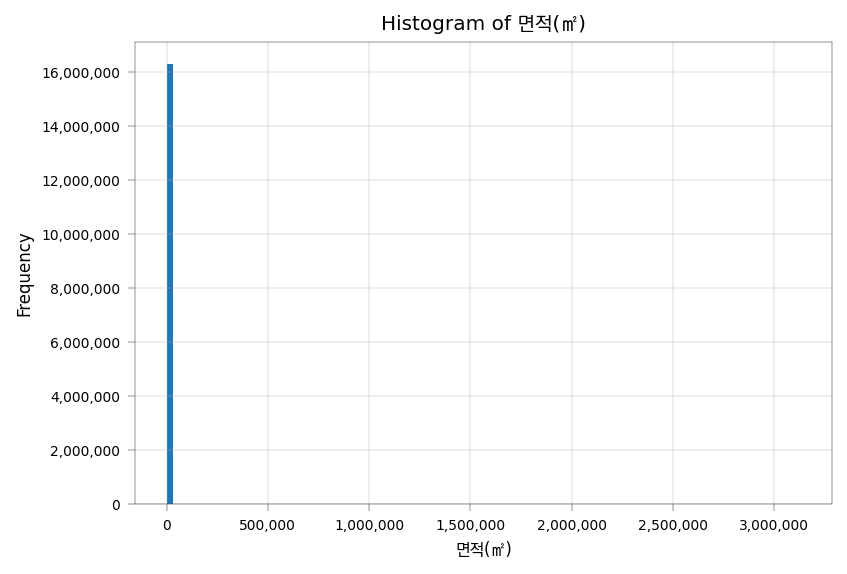

In [46]:
def plot_histogram(df, value_column, bins=100):
    """
    면적(㎡) 값을 100개의 구간으로 나누어 히스토그램을 그리는 함수.

    Parameters:
    df (dask.dataframe.DataFrame): 분석할 pandas

    value_column (str): 히스토그램을 그릴 값의 열 이름.
    bins (int): 히스토그램의 구간 개수 (기본값: 100).

    Returns:
    None
    """

    # 연면적(㎡) 값을 히스토그램으로 그리기
    ## plt.figure(figsize=(10, 6))
    ## plt.hist(df[value_column], bins=bins, color='skyblue', edgecolor='black')
    plt.figure()
    plt.hist(df[value_column], bins=bins)
    plt.title("Histogram of 면적(㎡)")
    plt.xlabel("면적(㎡)")
    plt.ylabel("Frequency")
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style="plain", useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter(
        "{x:,.0f}"
    )  # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_histogram(filtered_joined_ddf, "면적(㎡)", bins=100)

이상치가 미치는 전체 데이터의 영향을 확인하기 위하여 면적의 상위값을 0.1%~15%까지 1%씩 가중하여 히스토그램 그림.


In [47]:
# 면적(㎡) 칼럼에 상용로그를 취하여 새로운 컬럼으로 저장
filtered_joined_ddf["상용로그_면적"] = np.log10(filtered_joined_ddf["면적(㎡)"])

In [48]:
filtered_joined_ddf["상용로그_면적"].dtype

dtype('float64')

In [49]:
with pd.option_context("display.float_format", "{:,.3f}".format):
    display(filtered_joined_ddf["상용로그_면적"].describe())

count   16,306,376.000
mean             1.969
std              0.500
min             -2.426
25%              1.672
50%              1.945
75%              2.259
max              6.496
Name: 상용로그_면적, dtype: float64

In [50]:
with pd.option_context("display.float_format", "{:,.6f}".format):
    display(filtered_joined_ddf["면적(㎡)"].describe())

count   16,306,376.000000
mean           191.769703
std          1,356.763913
min              0.003750
25%             46.940000
50%             88.020000
75%            181.380000
max      3,131,783.000000
Name: 면적(㎡), dtype: float64

In [51]:
with pd.option_context("display.float_format", "{:,.3f}".format):
    display(filtered_joined_ddf.head())

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.210
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.588
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.582
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.342
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,0.000,0.000,163.340,11,01000,주택,163.240,1975,True,1.946


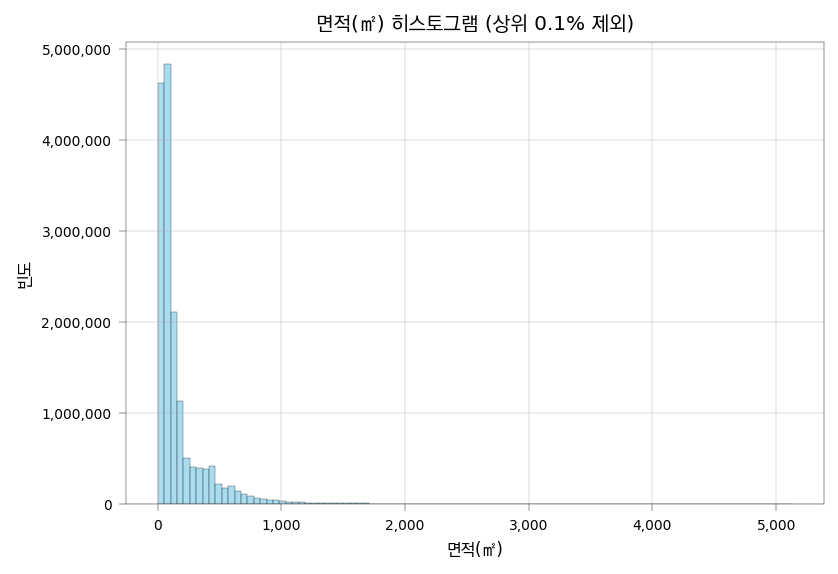

In [52]:
def plot_area_histogram(df):
    # 면적(㎡) 칼럼의 상위 0.1%를 제외한 데이터 추출
    quantile_999 = df["면적(㎡)"].quantile(0.999)
    filtered_df = df[df["면적(㎡)"] <= quantile_999]

    # 100개의 구간으로 나누기
    bins = np.linspace(
        filtered_df["면적(㎡)"].min(), filtered_df["면적(㎡)"].max(), 100
    )

    # 히스토그램 그리기
    plt.hist(
        filtered_df["면적(㎡)"],
        bins=bins,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    plt.xlabel("면적(㎡)")
    plt.ylabel("빈도")
    plt.title("면적(㎡) 히스토그램 (상위 0.1% 제외)")
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style="plain", useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter(
        "{x:,.0f}"
    )  # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_ddf)

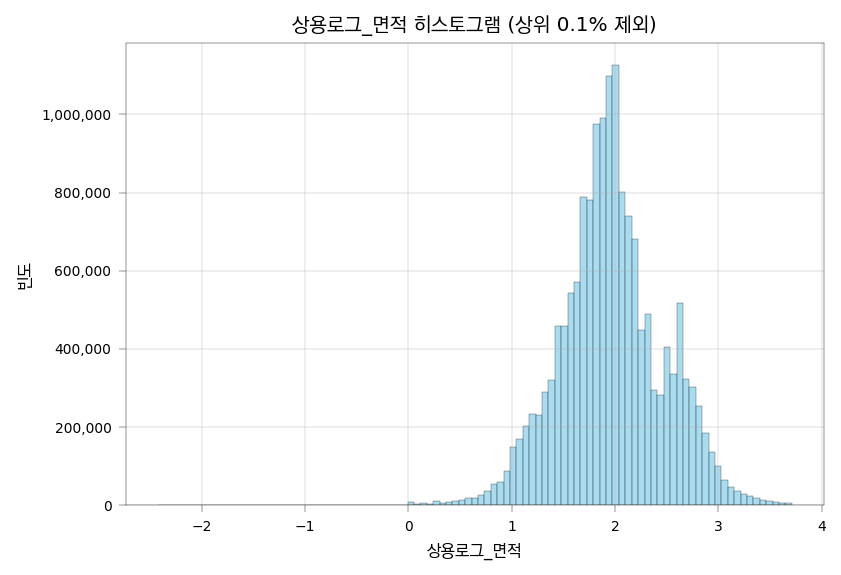

In [53]:
def plot_area_histogram(df, column_name):
    # 면적(㎡) 칼럼의 상위 0.1%를 제외한 데이터 추출
    quantile_999 = df[column_name].quantile(0.999)
    filtered_df = df[df[column_name] <= quantile_999]

    # 100개의 구간으로 나누기
    bins = np.linspace(
        filtered_df[column_name].min(), filtered_df[column_name].max(), 100
    )

    # 히스토그램 그리기
    plt.hist(
        filtered_df[column_name],
        bins=bins,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    plt.xlabel(column_name)
    plt.ylabel("빈도")
    plt.title(f"{column_name} 히스토그램 (상위 0.1% 제외)")
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style="plain", useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter(
        "{x:,.0f}"
    )  # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_ddf, "상용로그_면적")

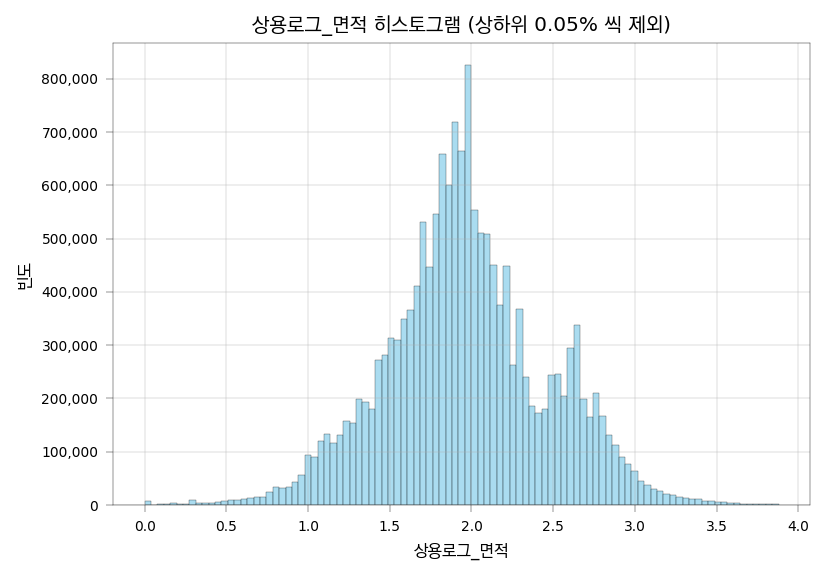

In [54]:
def plot_area_histogram(df, column_name):
    # 면적(㎡) 칼럼의 상하위 0.05% 씩을 제외한 데이터 추출
    quantile_low = df[column_name].quantile(0.0005)
    quantile_high = df[column_name].quantile(0.9995)
    filtered_df = df[
        (df[column_name] >= quantile_low) & (df[column_name] <= quantile_high)
    ]

    # 100개의 구간으로 나누기
    bins = np.linspace(
        filtered_df[column_name].min(), filtered_df[column_name].max(), 100
    )

    # 히스토그램 그리기
    plt.hist(
        filtered_df[column_name],
        bins=bins,
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    plt.xlabel(column_name)
    plt.ylabel("빈도")
    plt.title(f"{column_name} 히스토그램 (상하위 0.05% 씩 제외)")
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style="plain", useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter(
        "{x:,.0f}"
    )  # This formats the number with commas
    # plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_ddf, "상용로그_면적")

상용로그\_면적의 상하위 0.05% 이내의 값을 새로운 컬럼을 추가하여 표시


In [55]:
# filtered_joined_ddf에서 '상용로그_면적' 칼럼의 상위 및 하위 0.05% 값을 계산합니다.
upper_threshold = filtered_joined_ddf["상용로그_면적"].quantile(0.9995)  # 상위 0.05%
lower_threshold = filtered_joined_ddf["상용로그_면적"].quantile(0.0005)  # 하위 0.05%

# 'Upper_lower' 칼럼에 조건에 따라 상위/하위/일반을 지정합니다.
filtered_joined_ddf["Upper_lower"] = "일반"
filtered_joined_ddf.loc[
    filtered_joined_ddf["상용로그_면적"] > upper_threshold, "Upper_lower"
] = "상위"
filtered_joined_ddf.loc[
    filtered_joined_ddf["상용로그_면적"] < lower_threshold, "Upper_lower"
] = "하위"

# 결과를 확인합니다.
filtered_joined_ddf.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,0,163,11,01000,주택,163,1975,True,2,일반


In [56]:
filtered_joined_ddf.Upper_lower.value_counts()

Upper_lower
일반    16294698
상위        8154
하위        3524
Name: count, dtype: int64

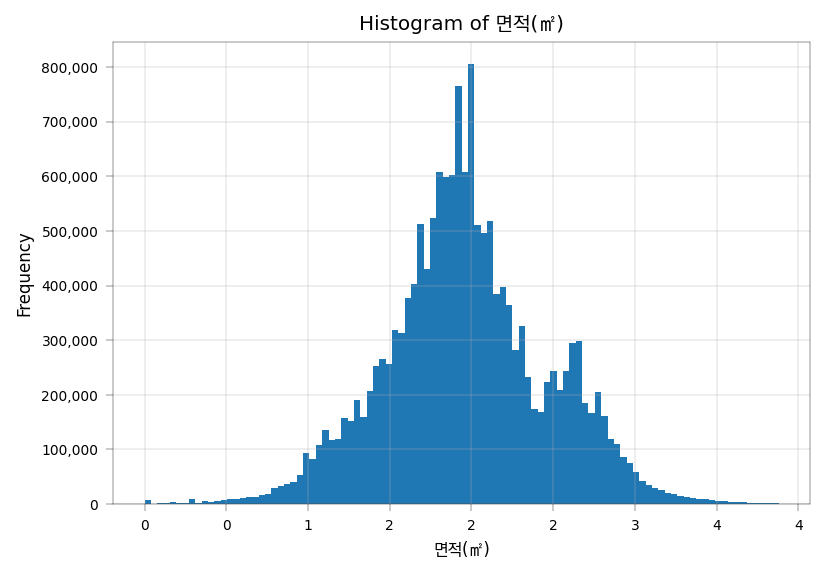

In [57]:
plot_histogram(
    filtered_joined_ddf[filtered_joined_ddf["Upper_lower"] == "일반"],
    "상용로그_면적",
    bins=100,
)

In [58]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    # display(filtered_joined_ddf[filtered_joined_ddf['Upper_lower'] == '일반'].nlargest(1, '면적(㎡)'))
    display(
        filtered_joined_ddf[filtered_joined_ddf["Upper_lower"] == "일반"].nsmallest(
            1, "면적(㎡)"
        )
    )

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,
11110-11121,10,지하,1,지1층,21,철근콘크리트구조,철근콘크리트조,03999,기타제1종근린생활시설,<NA>,1,0,<NA>,20141225,11110,14100,0,627,272,"1,212",21,03000,근린생활시설,"1,212",1986,True,0,일반


통계용 최종 데이터 프레임 완성!


In [59]:
f_df = filtered_joined_ddf[filtered_joined_ddf["Upper_lower"] == "일반"]

In [60]:
f_df["면적(㎡)"].describe()

count   16,294,698
mean           184
std            323
min              1
25%             47
50%             88
75%            181
max          7,591
Name: 면적(㎡), dtype: float64

층별개요의 주*용도*코드는 세부용도를 기준으로 수록되어 있으며, 행정표준코드관리시스템에는 759개의 용도 코드가 있고, 현행 사용중인 코드는 5자리 534개이며, 2009년 일괄 개정되어 4자리 기존코드는 225개가 있음. 데이터 상으로는 698개가 있고, 코드 오기는 2개 층이 문자로 입력되어 오기로 확인.
주택 코드를 시리즈로 저장하고 이와 비교하여 각 층의 주택여부를 최종 데이터에 컬럼을 추가하여 표기


In [61]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(f_df.주_용도_코드.value_counts())

주_용도_코드
01001    5057501
02001    1983505
01003    1751066
02003    1037084
03001     762745
04001     461517
18001     439032
04402     427869
17100     404411
21101     324173
03999     320967
04999     194626
02002     137421
04005     120643
17999     118299
02005     105771
15102      97128
21999      88800
04010      88555
04499      88175
03005      80769
14202      76842
03002      75188
14204      70716
18999      67637
14299      61624
06101      50377
20001      49085
03011      48337
11201      45157
03021      41746
10101      40721
04006      39797
03199      39109
01002      34601
18101      34031
15199      31020
10003      30056
10999      30037
10104      29118
17301      27929
04035      27632
19001      27020
10103      26301
03007      23948
03003      23374
17200      22930
04201      21178
16002      21144
11103      20068
02004      19717
04002      19620
04020      19285
10199      18552
04403      18485
09107      18397
10102      17991
11102      17063
04014 

In [62]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(f_df[f_df["주_용도_코드"] == "b0299"].head())

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,
26110-2984,20,지상,3,3,21,철근콘크리트구조,철근콘크리트조,b0299,<NA>,사무실,114,0,<NA>,20110414,26110,10600,0,143,114,574,21,03000,"점포, 사무실 , 단독주택",574,1975,True,2,일반
26110-3380,20,지상,6,6,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,528,0,<NA>,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-3380,20,지상,3,3,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,453,0,<NA>,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-3380,20,지상,5,5,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,528,0,<NA>,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-3380,20,지상,9,9,42,철골철근콘크리트구조,철골철근콘크리트,b0299,<NA>,업무시설,466,0,<NA>,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반


In [63]:
h_list = [
    "01000",
    "01001",
    "01002",
    "01003",
    "01004",
    "01005",
    "01006",
    "01007",
    "01008",
    "02000",
    "02001",
    "02002",
    "02003",
    "02004",
    "02005",
    "02006",
    "02007",
    "02008",
    "02009",
    "02010",
    "02011",
    "1000",
    "1002",
    "1003",
    "1004",
    "2000",
    "2001",
    "2002",
    "2003",
    "2004",
    "2005",
    "2006",
    "2007",
]
h_list

['01000',
 '01001',
 '01002',
 '01003',
 '01004',
 '01005',
 '01006',
 '01007',
 '01008',
 '02000',
 '02001',
 '02002',
 '02003',
 '02004',
 '02005',
 '02006',
 '02007',
 '02008',
 '02009',
 '02010',
 '02011',
 '1000',
 '1002',
 '1003',
 '1004',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007']

In [64]:
f_df["housing"] = f_df["주_용도_코드"].isin(h_list)
f_df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\4040378780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df["housing"] = f_df["주_용도_코드"].isin(h_list)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반,True
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반,True
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반,True
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반,True
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,163,11,01000,주택,163,1975,True,2,일반,True


주거용도의 층수는 11178188이고, 전체면적은 1919665783.922038이며, 층별 평균은 171.7331810774732d임. 비주거용도의 층수는 7143405이며, 전체면적은 1828998666.49204이며, 층별 평균은 256.040175027461임.


In [65]:
f_df.housing.value_counts()

housing
True     10160308
False     6134390
Name: count, dtype: int64

In [66]:
f_df[f_df["housing"]]["면적(㎡)"].sum()

1585295277.4694028

In [67]:
f_df[f_df["housing"]]["면적(㎡)"].mean()

156.02826976007054

In [68]:
f_df[~f_df["housing"]]["면적(㎡)"].sum()

1411761949.2734537

In [69]:
f_df[~f_df["housing"]]["면적(㎡)"].mean()

230.1389297507093

각 층을 가중치로 우리나라 건축물의 평균 사용승인년도는 1996.5976228158763이며, 24년 6월 기준 평균연령은 27.90237718412368세이다.
면적을 기준으로 우리나라 건축물의 평균 사용승인년도는 2003.2695815091042이며, 24년 6월 기준 평균연령은 21.230418490895772세이다.

면적 기준으로 주거용/비주거용을 살펴보면,면적기준 주거용도 사용승인연도 평균: 2002.317742587773 평균연령 22.182257412227045이며, 면적기준 비주거용도 사용승인연도 평균: 2004.2674693014803 평균연령 20.232530698519668


In [70]:
2024.5 - f_df["year"].astype(int).mean()

33.45323411332947

In [71]:
def weighted_avg(ddf_x):
    weights = ddf_x["면적(㎡)"]  # 면적을 가중치로 사용
    values = ddf_x["year"].astype(int)
    weighted_sum = (values * weights).sum()
    sum_of_weights = weights.sum()
    return weighted_sum / sum_of_weights


# year 컬럼의 가중평균 계산
weighted_average_year = weighted_avg(f_df)

print(
    "면적기준 year 가중평균:",
    weighted_average_year,
    "평균연령",
    2024.5 - weighted_average_year,
)

면적기준 year 가중평균: 1998.076393967535 평균연령 26.42360603246493


In [72]:
# 'housing' 컬럼이 True인 행들을 선택합니다.
housing_true_df = f_df[f_df["housing"]]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_true_df["면적(㎡)"]
year_values = housing_true_df["year"].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print(
    "면적기준 주거용도 사용승인연도 평균:",
    weighted_average,
    "평균연령",
    2024.5 - weighted_average,
)

면적기준 주거용도 사용승인연도 평균: 1997.2939092935678 평균연령 27.206090706432178


In [73]:
# 'housing' 컬럼이 false인 행들을 선택합니다.
housing_false_df = f_df[~f_df["housing"]]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_false_df["면적(㎡)"]
year_values = housing_false_df["year"].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print(
    "면적기준 비주거용도 사용승인연도 평균:",
    weighted_average,
    "평균연령",
    2024.5 - weighted_average,
)

면적기준 비주거용도 사용승인연도 평균: 1998.9550614078748 평균연령 25.544938592125163


층별 연령대 구간(5년단위) bin컬럼에 추가


In [74]:
# # 1924년부터 2023년까지의 연도 범위 생성
# years_range = list(range(1923, 2024))

# 구간을 담을 리스트 초기화
bins = []

# 1924년 이전을 하나의 구간으로 통합
bins.append(-1)

# 2015년 기준 100년 범위를 (마지막은 포함 안함, 따라서 +1)
# 5년 단위로 구간을 나누기
for year in range(2015 - 100, 2015 + 1, 5):
    bins.append(year)

# 리스트 출력
print(bins)


[-1, 1915, 1920, 1925, 1930, 1935, 1940, 1945, 1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015]


In [75]:
len(bins)

22

In [76]:
# 0세부터 100세 이상까지의 연령대 구간 리스트 생성
age_ranges = list(f"{y-5}-{y-1}년" for y in range(105, 0, -5))

# 마지막 구간을 100세 이상으로 변경
age_ranges[0] = "100년 이상"

# 결과 출력
print(age_ranges)

['100년 이상', '95-99년', '90-94년', '85-89년', '80-84년', '75-79년', '70-74년', '65-69년', '60-64년', '55-59년', '50-54년', '45-49년', '40-44년', '35-39년', '30-34년', '25-29년', '20-24년', '15-19년', '10-14년', '5-9년', '0-4년']


In [77]:
len(age_ranges)

21

In [78]:
f_df["bin"] = pd.cut(f_df["year"].astype(int), bins=bins, labels=age_ranges)
f_df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\626981024.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df["bin"] = pd.cut(f_df["year"].astype(int), bins=bins, labels=age_ranges)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,11,02000,연립주택,"1,152",1986,True,2,일반,True,25-29년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,25-29년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,25-29년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,2,일반,True,25-29년
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,11,01000,주택,163,1975,True,2,일반,True,40-44년


시군구별 주거, 비주거 충수와 면적 산출하여 CSV로 저장


In [79]:
pd.options.display.float_format = "{:,.0f}".format

# result = ddf_new.groupby('bin')['연면적(㎡)'].sum().compute()
result = f_df.groupby(["시군구_코드", "bin", "housing"]).agg(
    {"면적(㎡)": ["count", "sum"], "상용로그_면적": ["count", "sum"]}
)

result

면적(㎡)           상용로그_면적       
                                  count       sum         count    sum
시군구_코드 bin        housing                                        
11110       100년 이상 False         14     3,682            14     31
                       True          14       607            14     22
            95-99년    False         10       399            10     14
                       True          12       250            12     15
            90-94년    False         10     1,537            10     17
...                                 ...       ...           ...    ...
50130       10-14년    True        4173   552,938          4173  8,402
            5-9년      False       3493   858,451          3493  7,288
                       True        2777   403,833          2777  5,591
            0-4년      False       6492 1,667,942          6492 13,490
                       True        7572 1,166,912          7572 15,182

[10626 rows x 4 columns]

In [80]:
result.index

MultiIndex([('11110', '100년 이상', False),
            ('11110', '100년 이상',  True),
            ('11110',  '95-99년', False),
            ('11110',  '95-99년',  True),
            ('11110',  '90-94년', False),
            ('11110',  '90-94년',  True),
            ('11110',  '85-89년', False),
            ('11110',  '85-89년',  True),
            ('11110',  '80-84년', False),
            ('11110',  '80-84년',  True),
            ...
            ('50130',  '20-24년', False),
            ('50130',  '20-24년',  True),
            ('50130',  '15-19년', False),
            ('50130',  '15-19년',  True),
            ('50130',  '10-14년', False),
            ('50130',  '10-14년',  True),
            ('50130',    '5-9년', False),
            ('50130',    '5-9년',  True),
            ('50130',    '0-4년', False),
            ('50130',    '0-4년',  True)],
           names=['시군구_코드', 'bin', 'housing'], length=10626)

In [81]:
result.reset_index([1, 2]).index

Index(['11110', '11110', '11110', '11110', '11110', '11110', '11110', '11110',
       '11110', '11110',
       ...
       '50130', '50130', '50130', '50130', '50130', '50130', '50130', '50130',
       '50130', '50130'],
      dtype='string', name='시군구_코드', length=10626)

In [82]:
result.reset_index([1, 2]).columns

MultiIndex([(    'bin',      ''),
            ('housing',      ''),
            (  '면적(㎡)', 'count'),
            (  '면적(㎡)',   'sum'),
            ('상용로그_면적', 'count'),
            ('상용로그_면적',   'sum')],
           )

In [83]:
result.reset_index([1, 2]).reset_index().set_index(["시군구_코드", "bin", "housing"])

면적(㎡)           상용로그_면적       
                                  count       sum         count    sum
시군구_코드 bin        housing                                        
11110       100년 이상 False         14     3,682            14     31
                       True          14       607            14     22
            95-99년    False         10       399            10     14
                       True          12       250            12     15
            90-94년    False         10     1,537            10     17
...                                 ...       ...           ...    ...
50130       10-14년    True        4173   552,938          4173  8,402
            5-9년      False       3493   858,451          3493  7,288
                       True        2777   403,833          2777  5,591
            0-4년      False       6492 1,667,942          6492 13,490
                       True        7572 1,166,912          7572 15,182

[10626 rows x 4 columns]

In [84]:
df_sgg_name = pd.read_csv("data/code_sgg.csv", dtype=str)
df_sgg_name = df_sgg_name.set_index("시군구코드")
s_sgg = df_sgg_name.시군구명
s_sgg = s_sgg.rename_axis("시군구_코드")
s_sgg

시군구_코드
11000               서울특별시
11110        서울특별시 종로구
11140          서울특별시 중구
11170        서울특별시 용산구
11200        서울특별시 성동구
                 ...          
51790    강원특별자치도 화천군
51800    강원특별자치도 양구군
51810    강원특별자치도 인제군
51820    강원특별자치도 고성군
51830    강원특별자치도 양양군
Name: 시군구명, Length: 481, dtype: object

In [85]:
# Column name to remove
column_to_remove = s_sgg.name

# Check if the column exists before removing it
if column_to_remove in result.columns:
    result.drop(column_to_remove, axis=1, inplace=True)

result2 = result.copy()
result2.columns = result2.columns.to_flat_index()
result2 = result2.join(s_sgg)
result2

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin        housing                                       
11110       100년 이상 False                   14            3,682   
                       True                    14              607   
            95-99년    False                   10              399   
                       True                    12              250   
            90-94년    False                   10            1,537   
...                                           ...              ...   
50130       10-14년    True                  4173          552,938   
            5-9년      False                 3493          858,451   
                       True                  2777          403,833   
            0-4년      False                 6492        1,667,942   
                       True                  7572        1,166,912   

                                (상용로그_면적, count)  (상용로그_면적, sum)  \
시군구_코드 bin        housing                                                 
11110       100년 이상 False                        14                    31   
                       True                         14                    22   
            95-99년    False                        10                    14   
                       True                         12                    15   
            90-94년    False                        10                    17   
...                                                ...                   ...   
50130       10-14년    True                       4173                 8,402   
            5-9년      False                      3493                 7,288   
                       True                       2777                 5,591   
            0-4년      False                      6492                13,490   
                       True                       7572                15,182   

                                               시군구명  
시군구_코드 bin        housing                           
11110       100년 이상 False          서울특별시 종로구  
                       True           서울특별시 종로구  
            95-99년    False          서울특별시 종로구  
                       True           서울특별시 종로구  
            90-94년    False          서울특별시 종로구  
...                                                 ...  
50130       10-14년    True     제주특별자치도 서귀포시  
            5-9년      False    제주특별자치도 서귀포시  
                       True     제주특별자치도 서귀포시  
            0-4년      False    제주특별자치도 서귀포시  
                       True     제주특별자치도 서귀포시  

[10626 rows x 5 columns]

In [86]:
result2.to_csv("output/층별_연령_시군구_2015.csv", encoding="utf-8-sig")

In [87]:
f_df.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자', '시군구_코드', '법정동_코드', '주_부속_구분_코드_dong',
       '대지_면적(㎡)', '건축_면적(㎡)', '연면적(㎡)', '구조_코드_dong',
       '주_용도_코드_dong', '기타_용도_dong', '총_동_연면적(㎡)', 'year',
       'T_year', '상용로그_면적', 'Upper_lower', 'housing', 'bin'],
      dtype='object')

In [88]:
df_sggcode = f_df[["시군구_코드", "bin", "housing"]].reset_index()
unique_counts = df_sggcode.groupby(["시군구_코드", "bin", "housing"])[
    "관리_건축물대장_PK"
].nunique()
unique_counts.name = "동_수"
unique_counts

시군구_코드  bin         housing
11110        100년 이상  False         6
                         True          7
             95-99년     False         6
                         True         10
             90-94년     False         6
                                    ... 
50130        10-14년     True       2624
             5-9년       False      2210
                         True       1768
             0-4년       False      3824
                         True       3846
Name: 동_수, Length: 10626, dtype: int64

In [89]:
unique_counts.sum()

7350841

In [90]:
# Column name to remove
column_to_remove = unique_counts.name

# Check if the column exists before removing it
if column_to_remove in result2.columns:
    result2.drop(column_to_remove, axis=1, inplace=True)

result3 = result2.copy()
result3 = result3.join(unique_counts)
result3

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin        housing                                       
11110       100년 이상 False                   14            3,682   
                       True                    14              607   
            95-99년    False                   10              399   
                       True                    12              250   
            90-94년    False                   10            1,537   
...                                           ...              ...   
50130       10-14년    True                  4173          552,938   
            5-9년      False                 3493          858,451   
                       True                  2777          403,833   
            0-4년      False                 6492        1,667,942   
                       True                  7572        1,166,912   

                                (상용로그_면적, count)  (상용로그_면적, sum)  \
시군구_코드 bin        housing                                                 
11110       100년 이상 False                        14                    31   
                       True                         14                    22   
            95-99년    False                        10                    14   
                       True                         12                    15   
            90-94년    False                        10                    17   
...                                                ...                   ...   
50130       10-14년    True                       4173                 8,402   
            5-9년      False                      3493                 7,288   
                       True                       2777                 5,591   
            0-4년      False                      6492                13,490   
                       True                       7572                15,182   

                                               시군구명  동_수  
시군구_코드 bin        housing                                  
11110       100년 이상 False          서울특별시 종로구      6  
                       True           서울특별시 종로구      7  
            95-99년    False          서울특별시 종로구      6  
                       True           서울특별시 종로구     10  
            90-94년    False          서울특별시 종로구      6  
...                                                 ...    ...  
50130       10-14년    True     제주특별자치도 서귀포시   2624  
            5-9년      False    제주특별자치도 서귀포시   2210  
                       True     제주특별자치도 서귀포시   1768  
            0-4년      False    제주특별자치도 서귀포시   3824  
                       True     제주특별자치도 서귀포시   3846  

[10626 rows x 6 columns]

In [91]:
result.to_csv("output/동별_층별_연령_시군구_2015.csv", encoding="utf-8-sig")

층별 연령대 구간(1년단위) bin2컬럼에 추가


In [92]:
# # 1924년부터 2023년까지의 연도 범위 생성
# years_range = list(range(1923, 2024))

# 구간을 담을 리스트 초기화
bins2 = []

# 1924년 이전을 하나의 구간으로 통합
bins2.append(-1)

# 2015년 기준 100년 범위를 (마지막은 포함 안함, 따라서 +1)
# 1년 단위로 구간을 나누기
for year in range(2015 - 100, 2015 + 1, 1):
    bins2.append(year)

# 리스트 출력
print(bins2)

[-1, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]


In [93]:
len(bins2)

102

In [94]:
# 0세부터 100세 이상까지의 연령대 구간 리스트 생성
age_ranges2 = list(f"{y-1}년" for y in range(101, 0, -1))

# 마지막 구간을 100세 이상으로 변경
age_ranges2[0] = "100년 이상"

# 결과 출력
print(age_ranges2)

['100년 이상', '99년', '98년', '97년', '96년', '95년', '94년', '93년', '92년', '91년', '90년', '89년', '88년', '87년', '86년', '85년', '84년', '83년', '82년', '81년', '80년', '79년', '78년', '77년', '76년', '75년', '74년', '73년', '72년', '71년', '70년', '69년', '68년', '67년', '66년', '65년', '64년', '63년', '62년', '61년', '60년', '59년', '58년', '57년', '56년', '55년', '54년', '53년', '52년', '51년', '50년', '49년', '48년', '47년', '46년', '45년', '44년', '43년', '42년', '41년', '40년', '39년', '38년', '37년', '36년', '35년', '34년', '33년', '32년', '31년', '30년', '29년', '28년', '27년', '26년', '25년', '24년', '23년', '22년', '21년', '20년', '19년', '18년', '17년', '16년', '15년', '14년', '13년', '12년', '11년', '10년', '9년', '8년', '7년', '6년', '5년', '4년', '3년', '2년', '1년', '0년']


In [95]:
len(age_ranges2)

101

In [96]:
f_df["bin2"] = pd.cut(f_df["year"].astype(int), bins=bins2, labels=age_ranges2)
f_df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\3497224015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df["bin2"] = pd.cut(f_df["year"].astype(int), bins=bins2, labels=age_ranges2)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin,bin2
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,02000,연립주택,"1,152",1986,True,2,일반,True,25-29년,29년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,25-29년,29년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,25-29년,29년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,2,일반,True,25-29년,29년
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,01000,주택,163,1975,True,2,일반,True,40-44년,40년


bin2를 기준으로 시군구별로 데이터 합산하여 CSV파일로 출력


In [97]:
pd.options.display.float_format = "{:,.0f}".format

# result = ddf_new.groupby('bin')['연면적(㎡)'].sum().compute()
result_bin2 = f_df.groupby(["시군구_코드", "bin2", "housing"]).agg(
    {"면적(㎡)": ["count", "sum"], "상용로그_면적": ["count", "sum"]}
)

result_bin2

면적(㎡)         상용로그_면적      
                                  count     sum         count   sum
시군구_코드 bin2       housing                                     
11110       100년 이상 False         14   3,682            14    31
                       True          14     607            14    22
            99년       False          1      17             1     1
                       True           2      35             2     2
            98년       False          7     260             7     9
...                                 ...     ...           ...   ...
50130       2년        True        1431 237,019          1431 2,903
            1년        False       1516 482,481          1516 3,259
                       True        1647 202,581          1647 3,208
            0년        False       1584 379,188          1584 3,331
                       True        2753 444,194          2753 5,586

[51106 rows x 4 columns]

In [98]:
# Column name to remove
column_to_remove = s_sgg.name

# Check if the column exists before removing it
if column_to_remove in result_bin2.columns:
    result_bin2.drop(column_to_remove, axis=1, inplace=True)

result2_bin2 = result_bin2.copy()
result2_bin2.columns = result2_bin2.columns.to_flat_index()
result2_bin2 = result2_bin2.join(s_sgg)
result2_bin2

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin2       housing                                       
11110       100년 이상 False                   14            3,682   
                       True                    14              607   
            99년       False                    1               17   
                       True                     2               35   
            98년       False                    7              260   
...                                           ...              ...   
50130       2년        True                  1431          237,019   
            1년        False                 1516          482,481   
                       True                  1647          202,581   
            0년        False                 1584          379,188   
                       True                  2753          444,194   

                                (상용로그_면적, count)  (상용로그_면적, sum)  \
시군구_코드 bin2       housing                                                 
11110       100년 이상 False                        14                    31   
                       True                         14                    22   
            99년       False                         1                     1   
                       True                          2                     2   
            98년       False                         7                     9   
...                                                ...                   ...   
50130       2년        True                       1431                 2,903   
            1년        False                      1516                 3,259   
                       True                       1647                 3,208   
            0년        False                      1584                 3,331   
                       True                       2753                 5,586   

                                               시군구명  
시군구_코드 bin2       housing                           
11110       100년 이상 False          서울특별시 종로구  
                       True           서울특별시 종로구  
            99년       False          서울특별시 종로구  
                       True           서울특별시 종로구  
            98년       False          서울특별시 종로구  
...                                                 ...  
50130       2년        True     제주특별자치도 서귀포시  
            1년        False    제주특별자치도 서귀포시  
                       True     제주특별자치도 서귀포시  
            0년        False    제주특별자치도 서귀포시  
                       True     제주특별자치도 서귀포시  

[51106 rows x 5 columns]

In [99]:
df_sggcode = f_df[["시군구_코드", "bin2", "housing"]].reset_index()
unique_counts2 = df_sggcode.groupby(["시군구_코드", "bin2", "housing"])[
    "관리_건축물대장_PK"
].nunique()
unique_counts2.name = "동_수"
unique_counts2

시군구_코드  bin2        housing
11110        100년 이상  False         6
                         True          7
             99년        False         1
                         True          2
             98년        False         4
                                    ... 
50130        2년         True        728
             1년         False       813
                         True        884
             0년         False       902
                         True       1228
Name: 동_수, Length: 51106, dtype: int64

In [100]:
# Column name to remove
column_to_remove = unique_counts2.name

# Check if the column exists before removing it
if column_to_remove in result2_bin2.columns:
    result2_bin2.drop(column_to_remove, axis=1, inplace=True)

result3_bin2 = result2_bin2.copy()
result3_bin2 = result3_bin2.join(unique_counts2)
result3_bin2

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin2       housing                                       
11110       100년 이상 False                   14            3,682   
                       True                    14              607   
            99년       False                    1               17   
                       True                     2               35   
            98년       False                    7              260   
...                                           ...              ...   
50130       2년        True                  1431          237,019   
            1년        False                 1516          482,481   
                       True                  1647          202,581   
            0년        False                 1584          379,188   
                       True                  2753          444,194   

                                (상용로그_면적, count)  (상용로그_면적, sum)  \
시군구_코드 bin2       housing                                                 
11110       100년 이상 False                        14                    31   
                       True                         14                    22   
            99년       False                         1                     1   
                       True                          2                     2   
            98년       False                         7                     9   
...                                                ...                   ...   
50130       2년        True                       1431                 2,903   
            1년        False                      1516                 3,259   
                       True                       1647                 3,208   
            0년        False                      1584                 3,331   
                       True                       2753                 5,586   

                                               시군구명  동_수  
시군구_코드 bin2       housing                                  
11110       100년 이상 False          서울특별시 종로구      6  
                       True           서울특별시 종로구      7  
            99년       False          서울특별시 종로구      1  
                       True           서울특별시 종로구      2  
            98년       False          서울특별시 종로구      4  
...                                                 ...    ...  
50130       2년        True     제주특별자치도 서귀포시    728  
            1년        False    제주특별자치도 서귀포시    813  
                       True     제주특별자치도 서귀포시    884  
            0년        False    제주특별자치도 서귀포시    902  
                       True     제주특별자치도 서귀포시   1228  

[51106 rows x 6 columns]

In [101]:
result3_bin2.to_csv(
    "output/동별_층별_1년단위_연령_시군구_2015.csv", encoding="utf-8-sig"
)

면적기준 사용승인연도 주거/비주거 전국, 광역, 기초
로그면적기준 사용승인연도 주거/비주거 전국, 광역, 기초


In [102]:
def weighted_avg(ddf_x):
    weights = ddf_x["상용로그_면적"]  # 면적을 가중치로 사용
    values = ddf_x["year"].astype(int)
    weighted_sum = (values * weights).sum()
    sum_of_weights = weights.sum()
    return weighted_sum / sum_of_weights


# year 컬럼의 가중평균 계산
weighted_average_year = weighted_avg(f_df)

print(
    "상용로그_면적 기준 year 가중평균:",
    weighted_average_year,
    "평균연령",
    2024.5 - weighted_average_year,
)

상용로그_면적 기준 year 가중평균: 1992.923611193903 평균연령 31.57638880609693


In [103]:
# 'housing' 컬럼이 True인 행들을 선택합니다.
housing_true_df = f_df[f_df["housing"]]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_true_df["상용로그_면적"]
year_values = housing_true_df["year"].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print(
    "상용로그_면적 기준 주거용도 사용승인연도 평균:",
    weighted_average,
    "평균연령",
    2024.5 - weighted_average,
)

상용로그_면적 기준 주거용도 사용승인연도 평균: 1991.1747777641883 평균연령 33.32522223581168


In [105]:
import numpy as np

# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_mean_by_year = f_df.groupby("시군구_코드").apply(
    lambda x: np.average(x["year"].astype(np.int64), weights=x["면적(㎡)"])
)

print(weighted_mean_by_year)

시군구_코드
11110   1,993
11140   1,989
11170   1,993
11200   1,996
11215   1,995
         ... 
48870   1,990
48880   1,993
48890   1,992
50110   1,999
50130   1,997
Length: 253, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_40644\512770000.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_mean_by_year = f_df.groupby("시군구_코드").apply(


In [106]:
f_df.dtypes

층_구분_코드              string[pyarrow]
층_구분_코드_명           string[pyarrow]
층_번호                             Int64
층_번호_명                string[pyarrow]
구조_코드                 string[pyarrow]
구조_코드_명              string[pyarrow]
기타_구조                 string[pyarrow]
주_용도_코드              string[pyarrow]
주_용도_코드_명           string[pyarrow]
기타_용도                 string[pyarrow]
면적(㎡)                          float64
주_부속_구분_코드         string[pyarrow]
면적_제외_여부            string[pyarrow]
생성_일자                 string[pyarrow]
시군구_코드               string[pyarrow]
법정동_코드               string[pyarrow]
주_부속_구분_코드_dong    string[pyarrow]
대지_면적(㎡)                     float64
건축_면적(㎡)                     float64
연면적(㎡)                        float64
구조_코드_dong            string[pyarrow]
주_용도_코드_dong         string[pyarrow]
기타_용도_dong            string[pyarrow]
총_동_연면적(㎡)                  float64
year                      string[pyarrow]
T_year                               bool
상용로그_면적                 

면적기준 시군구별 건축물 평균 사용승인일


In [107]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_mean_by_year = f_df.groupby("시군구_코드").apply(
    lambda x: np.average(x["year"].astype(int), weights=x["면적(㎡)"])
)
weighted_mean_by_year.rename("면적_기준", inplace=True)

df_meanyearbysgg = s_sgg.to_frame().join(weighted_mean_by_year, how="right")
df_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\4115580039.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_mean_by_year = f_df.groupby("시군구_코드").apply(


,시군구명,면적_기준
시군구_코드,,
11110,서울특별시 종로구,"1,993"
11140,서울특별시 중구,"1,989"
11170,서울특별시 용산구,"1,993"
11200,서울특별시 성동구,"1,996"
11215,서울특별시 광진구,"1,995"
...,...,...
48870,경상남도 함양군,"1,990"
48880,경상남도 거창군,"1,993"
48890,경상남도 합천군,"1,992"


In [108]:
weighted2_mean_by_year = f_df.groupby("시군구_코드").apply(
    lambda x: np.average(x["year"].astype(int), weights=x["상용로그_면적"])
)
weighted2_mean_by_year.rename("상용로그면적_기준", inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted2_mean_by_year)
df_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\1869197806.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted2_mean_by_year = f_df.groupby("시군구_코드").apply(


,시군구명,면적_기준,상용로그면적_기준
시군구_코드,,,
11110,서울특별시 종로구,"1,993","1,989"
11140,서울특별시 중구,"1,989","1,983"
11170,서울특별시 용산구,"1,993","1,988"
11200,서울특별시 성동구,"1,996","1,991"
11215,서울특별시 광진구,"1,995","1,994"
...,...,...,...
48870,경상남도 함양군,"1,990","1,976"
48880,경상남도 거창군,"1,993","1,979"
48890,경상남도 합천군,"1,992","1,982"


In [109]:
weighted0_mean_by_year = f_df.groupby("시군구_코드").apply(
    lambda x: np.average(x["year"].astype(int))
)
weighted0_mean_by_year.rename("층별_기준", inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted0_mean_by_year)
df_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\2296435086.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted0_mean_by_year = f_df.groupby("시군구_코드").apply(


,시군구명,면적_기준,상용로그면적_기준,층별_기준
시군구_코드,,,,
11110,서울특별시 종로구,"1,993","1,989","1,988"
11140,서울특별시 중구,"1,989","1,983","1,982"
11170,서울특별시 용산구,"1,993","1,988","1,987"
11200,서울특별시 성동구,"1,996","1,991","1,990"
11215,서울특별시 광진구,"1,995","1,994","1,994"
...,...,...,...,...
48870,경상남도 함양군,"1,990","1,976","1,972"
48880,경상남도 거창군,"1,993","1,979","1,975"
48890,경상남도 합천군,"1,992","1,982","1,980"


In [110]:
f_df.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin,bin2
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,02000,연립주택,"1,152",1986,True,2,일반,True,25-29년,29년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,25-29년,29년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,3,일반,True,25-29년,29년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,02000,연립주택,"1,152",1986,True,2,일반,True,25-29년,29년
11110-10001,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,01000,주택,163,1975,True,2,일반,True,40-44년,40년


동별\_기준 평균연령 산출절차

1. index가 같은 행들의 중 주*용도*코드 별로 면적의 합계를 구하자 -> index, 주*용도*코드 그룹바이 면적(㎡) 컬럼 합계 agg
2. 중복된 인덱스를 제거하는데 동일한 index의 면적(㎡) 컬럼 합계


In [111]:
result = f_df.groupby([f_df.index, "주_용도_코드"])["면적(㎡)"].sum()

In [112]:
type(result)

pandas.core.series.Series

In [113]:
result

관리_건축물대장_PK  주_용도_코드
11110-1000          02002     1,152
11110-10001         01001       163
11110-10002         03999        56
11110-10003         04001        47
11110-10005         01001       122
                               ... 
50130-9993          18001        99
50130-9994          01001        40
50130-9996          01001        99
50130-9998          01001        66
50130-9999          01001        66
Name: 면적(㎡), Length: 8654100, dtype: float64

In [114]:
df_result = result.to_frame().reset_index()
df_result

,관리_건축물대장_PK,주_용도_코드,면적(㎡)
0,11110-1000,02002,"1,152"
1,11110-10001,01001,163
2,11110-10002,03999,56
3,11110-10003,04001,47
4,11110-10005,01001,122
...,...,...,...
8654095,50130-9993,18001,99
8654096,50130-9994,01001,40
8654097,50130-9996,01001,99
8654098,50130-9998,01001,66


In [115]:
idx = df_result.groupby("관리_건축물대장_PK")["면적(㎡)"].idxmax()
df_result.loc[idx]

,관리_건축물대장_PK,주_용도_코드,면적(㎡)
0,11110-1000,02002,"1,152"
1,11110-10001,01001,163
2,11110-10002,03999,56
3,11110-10003,04001,47
4,11110-10005,01001,122
...,...,...,...
8654095,50130-9993,18001,99
8654096,50130-9994,01001,40
8654097,50130-9996,01001,99
8654098,50130-9998,01001,66


In [116]:
f_su_df = df_result.loc[idx].set_index("관리_건축물대장_PK")
f_su_df

,주_용도_코드,면적(㎡)
관리_건축물대장_PK,,
11110-1000,02002,"1,152"
11110-10001,01001,163
11110-10002,03999,56
11110-10003,04001,47
11110-10005,01001,122
...,...,...
50130-9993,18001,99
50130-9994,01001,40
50130-9996,01001,99


In [117]:
df_building2.index

Dask Index Structure:
npartitions=42
11110-1000     string
11260-2023        ...
                ...  
48890-29482       ...
50130-9999        ...
Name: 관리_건축물대장_PK, dtype: string
Dask Name: assign-index, 10 graph layers

In [118]:
f_su_df = f_su_df.join(df_building2[["year", "T_year", "시군구_코드"]].compute())

In [119]:
f_su_df["housing"] = f_su_df["주_용도_코드"].isin(h_list)
f_su_df.head()

,주_용도_코드,면적(㎡),year,T_year,시군구_코드,housing
관리_건축물대장_PK,,,,,,
11110-1000,02002,"1,152",1986,True,11110,True
11110-10001,01001,163,1975,True,11110,True
11110-10002,03999,56,1965,True,11110,False
11110-10003,04001,47,1950,True,11110,False
11110-10005,01001,122,1975,True,11110,True


In [120]:
weighted0_mean_by_year = f_su_df.groupby("시군구_코드").apply(
    lambda x: np.average(x["year"].astype(int))
)
weighted0_mean_by_year.rename("동별_기준", inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted0_mean_by_year)
df_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\1946855580.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted0_mean_by_year = f_su_df.groupby("시군구_코드").apply(


,시군구명,면적_기준,상용로그면적_기준,층별_기준,동별_기준
시군구_코드,,,,,
11110,서울특별시 종로구,"1,993","1,989","1,988","1,982"
11140,서울특별시 중구,"1,989","1,983","1,982","1,972"
11170,서울특별시 용산구,"1,993","1,988","1,987","1,979"
11200,서울특별시 성동구,"1,996","1,991","1,990","1,983"
11215,서울특별시 광진구,"1,995","1,994","1,994","1,990"
...,...,...,...,...,...
48870,경상남도 함양군,"1,990","1,976","1,972","1,976"
48880,경상남도 거창군,"1,993","1,979","1,975","1,975"
48890,경상남도 합천군,"1,992","1,982","1,980","1,975"


In [121]:
df_meanyearbysgg.to_csv("output/평균연령_시군구_2015.csv", encoding="utf-8-sig")

주거용/비주거용 건축물 평균연령 구해보자


In [122]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_NH_mean_by_year = f_df.groupby(["시군구_코드", "housing"]).apply(
    lambda x: np.average(x["year"].astype(int), weights=x["면적(㎡)"])
)
weighted_NH_mean_by_year.rename("면적_기준", inplace=True)
df_NH_meanyearbysgg = s_sgg.to_frame().join(weighted_NH_mean_by_year, how="right")
df_NH_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\3551980270.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_NH_mean_by_year = f_df.groupby(["시군구_코드", "housing"]).apply(


시군구명  면적_기준
시군구_코드 housing                                    
11110       False          서울특별시 종로구      1,993
            True           서울특별시 종로구      1,994
11140       False            서울특별시 중구      1,987
            True             서울특별시 중구      1,995
11170       False          서울특별시 용산구      1,992
...                                      ...        ...
48890       True             경상남도 합천군      1,983
50110       False      제주특별자치도 제주시      1,999
            True       제주특별자치도 제주시      1,999
50130       False    제주특별자치도 서귀포시      1,999
            True     제주특별자치도 서귀포시      1,995

[506 rows x 2 columns]

In [123]:
weighted2_NH_mean_by_year = f_df.groupby(["시군구_코드", "housing"]).apply(
    lambda x: np.average(x["year"].astype(int), weights=x["상용로그_면적"])
)
weighted2_NH_mean_by_year.rename("상용로그면적_기준", inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted2_NH_mean_by_year)
df_NH_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\4200443211.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted2_NH_mean_by_year = f_df.groupby(["시군구_코드", "housing"]).apply(


시군구명  면적_기준  상용로그면적_기준
시군구_코드 housing                                                       
11110       False          서울특별시 종로구      1,993              1,988
            True           서울특별시 종로구      1,994              1,990
11140       False            서울특별시 중구      1,987              1,982
            True             서울특별시 중구      1,995              1,986
11170       False          서울특별시 용산구      1,992              1,988
...                                      ...        ...                ...
48890       True             경상남도 합천군      1,983              1,974
50110       False      제주특별자치도 제주시      1,999              1,997
            True       제주특별자치도 제주시      1,999              1,994
50130       False    제주특별자치도 서귀포시      1,999              1,996
            True     제주특별자치도 서귀포시      1,995              1,988

[506 rows x 3 columns]

In [124]:
weighted0_NH_mean_by_year = f_df.groupby(["시군구_코드", "housing"]).apply(
    lambda x: np.average(x["year"].astype(int))
)
weighted0_NH_mean_by_year.rename("층별_기준", inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted0_NH_mean_by_year)
df_NH_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\3871670650.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted0_NH_mean_by_year = f_df.groupby(["시군구_코드", "housing"]).apply(


시군구명  면적_기준  상용로그면적_기준  \
시군구_코드 housing                                                          
11110       False          서울특별시 종로구      1,993              1,988   
            True           서울특별시 종로구      1,994              1,990   
11140       False            서울특별시 중구      1,987              1,982   
            True             서울특별시 중구      1,995              1,986   
11170       False          서울특별시 용산구      1,992              1,988   
...                                      ...        ...                ...   
48890       True             경상남도 합천군      1,983              1,974   
50110       False      제주특별자치도 제주시      1,999              1,997   
            True       제주특별자치도 제주시      1,999              1,994   
50130       False    제주특별자치도 서귀포시      1,999              1,996   
            True     제주특별자치도 서귀포시      1,995              1,988   

                     층별_기준  
시군구_코드 housing             
11110       False        1,987  
            True         1,989  
11140       False        1,980  
            True         1,984  
11170       False        1,987  
...                        ...  
48890       True         1,971  
50110       False        1,995  
            True         1,992  
50130       False        1,995  
            True         1,986  

[506 rows x 4 columns]

In [125]:
weighted3_NH_mean_by_year = f_su_df.groupby(["시군구_코드", "housing"]).apply(
    lambda x: np.average(x["year"].astype(int))
)
weighted3_NH_mean_by_year.rename("동별_기준", inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted3_NH_mean_by_year)
df_NH_meanyearbysgg

C:\Users\USER\AppData\Local\Temp\ipykernel_40644\2133083726.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted3_NH_mean_by_year = f_su_df.groupby(["시군구_코드", "housing"]).apply(


시군구명  면적_기준  상용로그면적_기준  \
시군구_코드 housing                                                          
11110       False          서울특별시 종로구      1,993              1,988   
            True           서울특별시 종로구      1,994              1,990   
11140       False            서울특별시 중구      1,987              1,982   
            True             서울특별시 중구      1,995              1,986   
11170       False          서울특별시 용산구      1,992              1,988   
...                                      ...        ...                ...   
48890       True             경상남도 합천군      1,983              1,974   
50110       False      제주특별자치도 제주시      1,999              1,997   
            True       제주특별자치도 제주시      1,999              1,994   
50130       False    제주특별자치도 서귀포시      1,999              1,996   
            True     제주특별자치도 서귀포시      1,995              1,988   

                     층별_기준  동별_기준  
시군구_코드 housing                        
11110       False        1,987      1,981  
            True         1,989      1,982  
11140       False        1,980      1,973  
            True         1,984      1,972  
11170       False        1,987      1,979  
...                        ...        ...  
48890       True         1,971      1,969  
50110       False        1,995      1,997  
            True         1,992      1,988  
50130       False        1,995      1,994  
            True         1,986      1,982  

[506 rows x 5 columns]

In [126]:
df_NH_meanyearbysgg.to_csv(
    "output/주거비주거_평균연령_시군구_2015.csv", encoding="utf-8-sig"
)